# 09 — Deep Reinforcement Learning: Deep Q-Network (DQN)

**A portfolio chapter connecting tabular Q-learning to neural-network action-value estimation, with full numerical updates and a runnable CartPole experiment.**


**Roadmap**

1. RL + deep learning; Q-learning vs DQN; algorithm families and Q-network architecture.
2. DQN training at a glance; replay memory, mini-batch training, and online versus target network.
3. Mathematical updates; worked single-transition and mini-batch calculations; complete pseudocode; Double DQN.
4. Original Atari setting; Gymnasium CartPole implementation; training curves, evaluation, diagnostics and animation.

**Notation:** $s$ = current state, $a$ = recorded action, $r$ = reward, $s'$ = next state, $d$ = **true termination** indicator, $\theta$ = trainable online-network weights, $\theta^-$ = temporarily fixed target-network weights, $B$ = mini-batch size, $\gamma$ = discount factor. A time-limit *truncation* ends the rollout but is not automatically a true MDP termination.

## 1. Deep Reinforcement Learning: joining RL and deep learning

**Reinforcement learning (RL)** addresses *which action to take*. An agent observes state $S_t$, chooses action $A_t$, and receives reward $R_{t+1}$ and a new state $S_{t+1}$ from its environment. It seeks high **discounted future return**, not merely the immediate reward:

$$G_t=R_{t+1}+\gamma R_{t+2}+\gamma^2R_{t+3}+\cdots=\sum_{k=0}^{\infty}\gamma^kR_{t+k+1},\qquad 0\le\gamma<1.$$

**Deep learning (DL)** supplies a flexible function approximator. Instead of storing a different number for every state-action pair, a network with trainable parameters $\theta$ estimates action values:

$$\boxed{Q(s,a;\theta)\approx q^*(s,a)}.$$

The **integration** is the complete interaction/training loop:

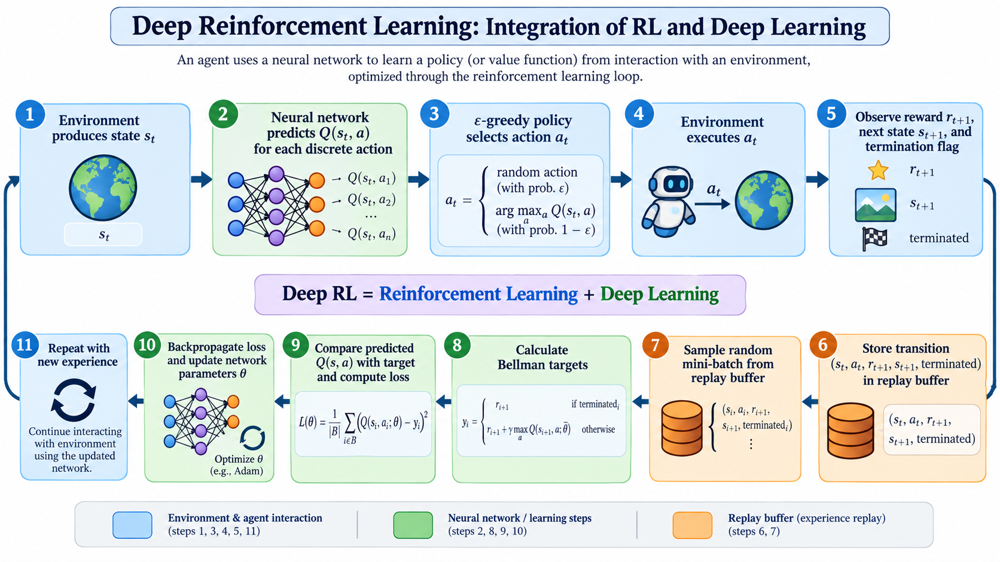

*How interaction, experience replay and neural-network optimization combine in deep reinforcement learning.*

**Important:** In supervised classification, the label is usually part of the given dataset. In DQN, the training target is **constructed** from observed reward and the network's own estimate of a future action value. It can change as learning proceeds. The reward is a scalar, potentially sparse, delayed, or noisy.

Deep networks can process raw pixels using CNNs, or numerical state vectors using MLPs. They often *learn useful representations*, but this does **not** mean preprocessing, normalization, frame stacking, or task design is never needed.

## 2. Tabular Q-learning versus DQN: what changes, and when to use each?

For tabular Q-learning, there is a separate table cell for every discrete $(s,a)$ pair. The standard update is

$$\boxed{Q(S_t,A_t)\leftarrow Q(S_t,A_t)+\alpha\Big[R_{t+1}+\gamma\max_{a'}Q(S_{t+1},a')-Q(S_t,A_t)\Big]}.$$

DQN retains this **Bellman optimality idea**, but replaces the explicit table by a parameterized network $Q(s,a;\theta)$ and adjusts $\theta$ through a gradient-based loss.

| Question | Tabular Q-learning | Deep Q-Network (DQN) |
|---|---|---|
| Where are Q-values stored? | One entry per state-action pair | Shared neural-network weights $\theta$ |
| Input representation | Discrete state index | Numeric feature vector or preprocessed image |
| Prediction | `Q[state, action]` lookup | Neural-network forward pass |
| Learning update | Directly modify one table entry | Compute Bellman target, loss, gradient, and update network weights |
| Generalization | None between unrelated table entries | Can generalize to similar/unseen observations |
| Memory | $O(|\mathcal S||\mathcal A|)$ table | Model parameters + replay memory |
| Computational cost | Cheap updates | Forward/backward passes can be expensive |
| Typical strengths | Small discrete environments, good interpretability | Large/continuous observation spaces with **discrete actions** |
| Typical limitations | Explodes with many/continuous states | More hyperparameters, instability, poorer sample efficiency possible |

**Example 1: Taxi-v3 (tabular is natural).** The commonly used discrete representation has 500 states and 6 actions, so a simple Q-table has $500\times6=3{,}000$ entries. A neural net adds complexity with little necessity for this small representation.

**Example 2: CartPole-v1 (DQN is natural).** Observations are real-valued: cart position, cart velocity, pole angle, and angular velocity. Exact states are rarely revisited; assigning a unique table row to every precise combination is impractical. A neural network maps similar continuous observations to related Q-values.

**Use DQN when** observations are high-dimensional or continuous, **and actions are finite/discrete**, and there is enough interaction data and computation. **Prefer tabular Q-learning when** the discrete state-action space is small and well-defined. DQN does **not** automatically outperform a well-designed simpler solution. Standard DQN is not designed to maximize over a continuous action space without modifications.

## 3. Deep RL algorithm families

A useful classification is **model-based vs. model-free**:

- **Model-based:** uses known or learned transition/reward dynamics to plan (sometimes alongside value/policy networks).
- **Model-free, value-based:** learns state/action values, then chooses actions from them. Examples: DQN, Double DQN, Dueling DQN.
- **Model-free, policy-gradient:** learns a parameterized policy directly. Examples: REINFORCE, PPO (PPO may additionally train a critic).
- **Actor-critic:** learns an actor/policy with a learned critic/value estimate. Examples: A2C, A3C, DDPG, SAC, PPO implementations with a value critic.

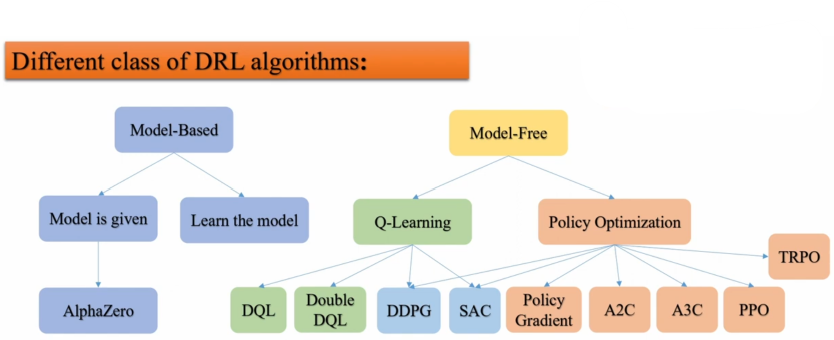

Here, we focus on **model-free, off-policy, value-based DQN**.

## 4. Neural-network representation of $Q(s,a)$

A discrete-action DQN typically takes **one state** as input and returns **one Q-value per action** in a **single forward pass**:

$$\boxed{\mathbf q_{\theta}(s)=\begin{bmatrix}Q(s,a_0;\theta)\\Q(s,a_1;\theta)\\\vdots\\Q(s,a_{m-1};\theta)\end{bmatrix}\in\mathbb R^m}.$$

This is more efficient than feeding each $(s,a)$ pair through a separate network pass when there are only a few discrete actions.

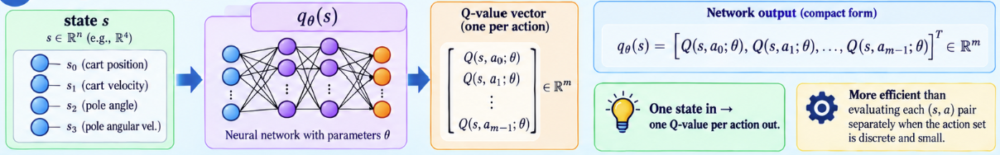




**For CartPole, the network we will code is**

$$\underbrace{\mathbb R^4}_{\text{observation}}\xrightarrow{\text{Linear }4\to128,\ \mathrm{ReLU}}\mathbb R^{128}\xrightarrow{\text{Linear }128\to128,\ \mathrm{ReLU}}\mathbb R^{128}\xrightarrow{\text{Linear }128\to2}\underbrace{[Q(s,0),Q(s,1)]}_{\text{two actions}}.$$

For any fully connected layer:

$$\boxed{\mathbf z^{(l)}=W^{(l)}\mathbf a^{(l-1)}+\mathbf b^{(l)},\quad \mathbf a^{(l)}=\operatorname{ReLU}(\mathbf z^{(l)})}.$$

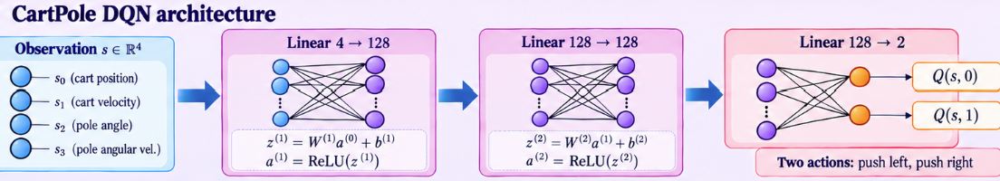

The **last layer is linear** (no softmax), because Q-values are estimates of returns, not probabilities and not constrained to sum to one. The greedy action is $\arg\max_a Q(s,a;\theta)$.

**Why CNNs for Atari?** Each screen is an image with spatial structure, so convolutional layers are more suitable than a giant raw-pixel fully-connected input. By contrast, CartPole already supplies a compact four-number observation, so an MLP is appropriate.

### 4.1 What the output does *not* mean

If $Q(s,:)=[2.0,4.5]$, the network estimates that action 1 has higher **future discounted return** than action 0. The numbers need not lie between 0 and 1 or sum to 1; they are **not** the probability of success. The greedy policy chooses $a^*=\arg\max_a Q(s,a;\theta)=1$. During training, the agent can still explore using $\varepsilon$-greedy.

The CartPole model uses $4\to128\to128\to2$ with ReLU hidden activations and **linear final outputs**, so one forward pass returns $Q(s,0)$ and $Q(s,1)$ together.

## 5. The full DQN learning cycle before the mathematics

DQN has **one online network and one target network** (not two separate target networks). They have the same architecture and begin with identical weights. Each plays a different role:

| Stage | What happens? | Why does it happen? |
|---|---|---|
| Initialize | Create $Q_{\text{online}}(s,a;\theta)$, copy $\theta$ to $\theta^-$, start empty replay memory $\mathcal D$ | Give predictions, an initial fixed reference and a place to save experience |
| Interact | Online network estimates $Q(s,:)$; $\varepsilon$-greedy picks an action | Make decisions and explore uncertain alternatives |
| Record | Environment returns $(s,a,r,s',d)$ and the agent stores it in $\mathcal D$ | Keep evidence for later training |
| Sample | Randomly select $B$ transitions from $\mathcal D$ | Mix earlier and recent experiences in one training step |
| Predict | Online network computes $Q(s_i,a_i;\theta)$ for the **stored actions** | Measure current predictions for what the agent actually did |
| Target | Target network estimates $\max_{a'}Q(s'_i,a';\theta^-)$ | Construct a temporarily stable Bellman learning target |
| Update | Average losses over the batch and backpropagate through **online** weights | One optimizer step uses information from the whole mini-batch |
| Synchronize | Periodically copy $\theta^-\leftarrow\theta$ | Refresh the future-value reference without moving it every update |

**Two loops happen at different frequencies:** the environment generates one transition per step; a replay mini-batch is trained on after sufficient memory has accumulated (usually once or more per step). The target network is copied **less often**. Replay warm-up (e.g., 1,000 transitions) prevents training on a tiny, narrowly sampled buffer.

## 6. Replay buffer and mini-batches: what they actually do

### 6.1 Why save transitions instead of using only the newest one?

A trajectory visits nearby states sequentially: $s_1\to s_2\to s_3\to\cdots$. These experiences are strongly correlated. Training only on the latest transition can produce noisy updates and cause the network to focus too heavily on very recent states. It also discards data that took environment interactions to collect.

A **replay buffer** is a bounded memory $\mathcal D=\{(s_i,a_i,r_i,s'_i,d_i)\}$. After each environment action, one transition is appended. When capacity $N$ is reached, the oldest transitions are overwritten. The buffer **does not learn** and has no trainable weights: it only stores experience.

### 6.2 What does the random mini-batch do?

A **mini-batch is a randomly selected group of transitions from the buffer**, not a separate network. Example: if a buffer has 1,000 transitions and $B=4$, a draw might select indices $[730,12,508,91]$ (without replacement in this notebook). For every selected transition, compute a target $y_i$ and an online prediction $\hat y_i$. The optimizer performs **one** parameter update using the *average gradient* across those four losses.

$$\boxed{L_B(\theta)=\frac1B\sum_{i\in\mathcal B}\underbrace{\frac12\big(y_i-Q(s_i,a_i;\theta)\big)^2}_{L_i(\theta)}}$$
$$\boxed{\nabla_\theta L_B=\frac1B\sum_{i\in\mathcal B}\nabla_\theta L_i\!,\qquad\theta_{\rm new}=\theta_{\rm old}-\alpha\nabla_\theta L_B\quad(\text{plain SGD}).}$$

**Important distinctions:** We average *sample gradients* (equivalently differentiate average loss), **not** model weights and **not** the sampled rewards alone. Different samples may recommend updates in opposite directions; their gradients combine before the optimizer changes the shared parameters. With Adam, gradients are still based on the batch-mean loss, but Adam's weight-update rule is different from plain SGD.

### 6.3 Why the two techniques work together

- **Replay memory** stores reusable experience and random sampling reduces temporal correlation, although samples are not guaranteed independent.
- **Mini-batch learning** combines gradients from multiple experiences in one update and permits efficient tensor operations.
- **Target network** serves a *different purpose*: slowing movement of the Bellman bootstrap targets.

**Replay warm-up:** collect $W$ transitions before optimizing; typically start once $|\mathcal D|\ge \max(W,B)$. **Off-policy compatibility:** data gathered under earlier $\varepsilon$-greedy behavior can still be used because the Bellman target considers a greedy next action, rather than insisting on the action originally taken after $s'$.

```text
Correlated timeline:       T1 -> T2 -> T3 -> T4 -> ... -> T1000
Replay memory:            [T1, T2, T3, T4, ..., T1000]
Random mini-batch:         [T730, T12, T508, T91]
Predictions / targets:       each transition i produces Q(s_i,a_i) and y_i
Average loss:              (L_730 + L_12 + L_508 + L_91) / 4
Optimizer:                 ONE online-network weight update
```

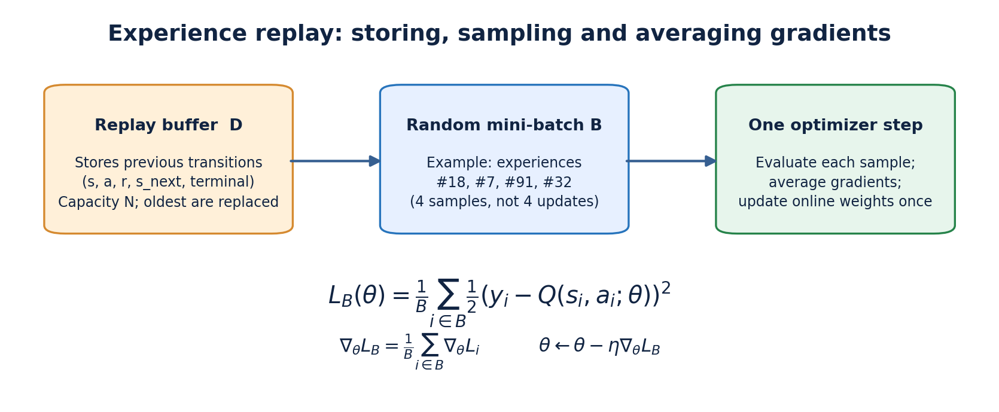

*Replay memory stores transitions; random mini-batches are used to calculate one averaged gradient update.*

## 7. Why two Q-networks? Online prediction versus target

### 7.1 One network creates a moving target

For a nonterminal transition, the Q-learning target includes a *future Q-estimate*: $r+\gamma\max_{a'}Q(s',a')$. If the same trainable weights $\theta$ are used on both sides, changing the network to improve the current-state prediction may immediately change its own next-state target:

$$Q(s,a;\theta)\quad\longrightarrow\quad r+\gamma\max_{a'}Q(s',a';\theta).$$

Example: suppose the prediction is 6 and its training target is 10. An update might increase the prediction to 7, but also move the target to 12. The learner is trying to fit a reference that changes as it learns. This is the **moving-target problem**; neural-network approximation, bootstrapping and off-policy updates can compound instability.

### 7.2 Two networks solve different tasks

| | Online (prediction) network | Target network |
|---|---|---|
| Parameters | $\theta$ | $\theta^-$ |
| Input in replay training | Stored *current* states $s_i$ | Stored *next* states $s'_i$ |
| Output used | $\hat y_i=Q(s_i,a_i;\theta)$ | $\max_{a'}Q(s'_i,a';\theta^-)$ |
| How its weights change | Backpropagation + optimizer on batch mean loss | Explicit copy from online network every $C$ steps |
| Used to select environment actions? | Yes, with $\varepsilon$-greedy | No in basic DQN |

At initialization, $\theta^-=\theta$. During training, **only online parameters get loss gradients**. Between target synchronizations, the target network is held fixed, giving a more stable reference for the same replay transitions. Every $C$ environment steps, do a **hard update**:

$$\boxed{\theta^-\leftarrow\theta.}$$

The two networks will usually **disagree between copies**. That is intentional. The target network does **not** learn the mini-batch directly; its weights are periodically copied from the network that *does* learn. A fixed reference slows drift but is still an imperfect estimate, and training is not guaranteed to converge.

### 7.3 Why this is not yet Double DQN

**Standard DQN already uses two networks.** For a next state, its target network both **chooses** the maximum-valued action and **evaluates** that action. **Double DQN** keeps the same two networks but lets the online network choose the next action and the target network evaluate it. This reduces a different issue: systematic overestimation from maximizing noisy value estimates. The side-by-side numerical comparison appears in Section 13.

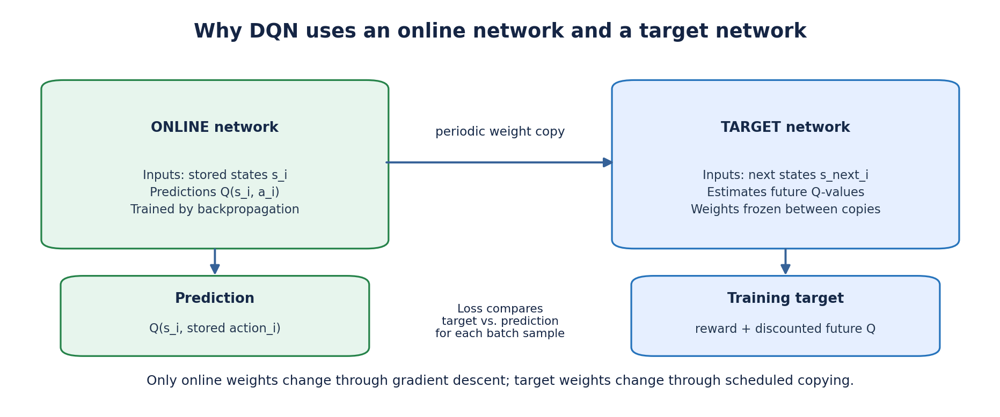

*One online prediction network is trained by backpropagation; one temporarily frozen target network supplies bootstrap targets.*

## 8. Deriving the DQN learning target, loss, and update

### 8.1 Begin with the Bellman optimality target

The ideal action value obeys

$$q^*(s,a)=\mathbb E\left[R_{t+1}+\gamma\max_{a'}q^*(S_{t+1},a')\mid S_t=s,A_t=a\right].$$

We do not know $q^*$; DQN uses a sampled transition $j=(s_j,a_j,r_j,s'_j,d_j)$ and a **frozen target network** with parameters $\theta^-$:

$$\boxed{y_j=r_j+\gamma(1-d_j)\max_{a'}Q(s'_j,a';\theta^-)}.$$

Here $d_j=1$ for a **true MDP termination**, otherwise $d_j=0$. Thus

$$y_j=\begin{cases}r_j,&\text{terminal transition},\\r_j+\gamma\max_{a'}Q(s'_j,a';\theta^-),&\text{nonterminal transition}.\end{cases}$$

The **online/prediction network** with parameters $\theta$ supplies $\hat y_j=Q(s_j,a_j;\theta)$. Its prediction error is $e_j=y_j-\hat y_j$.

### 8.2 Form the loss over a replay mini-batch

For mini-batch $B$:

$$\boxed{L_B(\theta)=\frac{1}{2|B|}\sum_{j\in B}\underbrace{\left[y_j-Q(s_j,a_j;\theta)\right]^2}_{\text{squared TD error}}}.$$

The factor $\tfrac12$ is optional: it cancels the 2 upon differentiation. If using the ordinary mean-square loss **without** $\tfrac12$, the gradient is twice as large for fixed data.

### 8.3 Differentiate, keeping the target fixed

With $y_j$ treated as a constant during this optimizer step (a **semi-gradient**),

$$\begin{aligned}
\nabla_{\theta}L_B(\theta)&=\frac1{|B|}\sum_{j\in B}\left[Q(s_j,a_j;\theta)-y_j\right]\nabla_{\theta}Q(s_j,a_j;\theta),\\
\boxed{\theta\leftarrow\theta+\frac\alpha{|B|}\sum_{j\in B}(y_j-Q(s_j,a_j;\theta))\nabla_{\theta}Q(s_j,a_j;\theta)}&\quad\text{(SGD update).}
\end{aligned}$$

Adam will be used in the experiment instead of plain SGD; its adaptive update is different, but it uses the same loss gradients. We deliberately **do not** differentiate through $y_j$.

**Difference from supervised learning:** The DQN target contains $\max_{a'}Q(s',a';\theta^-)$, an estimated future value. Periodically updating $\theta^-$ changes future training targets. This is why a target network is used to slow target drift.

## 9. Fully worked numerical example: **every step of one DQN update**

To make the calculation possible on paper, use a tiny **two-input → two-ReLU-neuron → two-action-output** network. It has the same forward/backward operations as a deep network, but is small enough for arithmetic. **This pedagogical network is not the larger CartPole architecture used later.**

### 9.1 Transition, hyperparameters, and initial networks

Suppose one replay transition is

$$\boxed{s=\begin{bmatrix}2\\1\end{bmatrix},\ a=0,\ r=1,\ s'=\begin{bmatrix}1\\2\end{bmatrix},\ \mathrm{terminated}=0.}$$

Choose discount $\gamma=0.9$ and **manual SGD learning rate** $\alpha=0.1$.

Initial **online** parameters are

$$W^{(1)}=\begin{bmatrix}0.5&-0.2\\0.1&0.4\end{bmatrix},\quad b^{(1)}=\begin{bmatrix}0.1\\0\end{bmatrix},$$

$$W^{(2)}=\begin{bmatrix}0.4&0.2\\-0.3&0.5\end{bmatrix},\quad b^{(2)}=\begin{bmatrix}0.1\\0\end{bmatrix}.$$

Assume the **target network** is initially an identical but **separate, frozen copy**, $\theta^-=\theta_{\rm initial}$.

### 9.2 Online forward pass for current state $s$

Compute hidden preactivations:

$$z^{(1)}=W^{(1)}s+b^{(1)}=\begin{bmatrix}0.5(2)-0.2(1)+0.1\\0.1(2)+0.4(1)+0\end{bmatrix}=\begin{bmatrix}0.9\\0.6\end{bmatrix}.$$

ReLU retains positive values:

$$h=\operatorname{ReLU}(z^{(1)})=\begin{bmatrix}0.9\\0.6\end{bmatrix}.$$

Compute **both** output Q-values in one forward pass:

$$\begin{aligned}
Q(s,0;\theta)&=0.4(0.9)+0.2(0.6)+0.1=\boxed{0.58},\\
Q(s,1;\theta)&=-0.3(0.9)+0.5(0.6)+0=\boxed{0.03}.
\end{aligned}$$

The recorded replay action is $a=0$, so **the prediction used in the loss is** $\hat y=Q(s,0;\theta)=0.58$; we do **not** train the $a=1$ output directly on this sample.

### 9.3 Frozen target-network forward pass for next state $s'$

The target network receives **next state** $s'=[1,2]^T$:

$$z'^-=\begin{bmatrix}0.5(1)-0.2(2)+0.1\\0.1(1)+0.4(2)\end{bmatrix}=\begin{bmatrix}0.2\\0.9\end{bmatrix},\qquad h'^-=\begin{bmatrix}0.2\\0.9\end{bmatrix}.$$

Then

$$\begin{aligned}Q(s',0;\theta^-)&=0.4(0.2)+0.2(0.9)+0.1=\boxed{0.36},\\
Q(s',1;\theta^-)&=-0.3(0.2)+0.5(0.9)=\boxed{0.39}.
\end{aligned}$$

The *next-state maximizing action* is $a'=1$, with value $\max_{a'}Q(s',a';\theta^-)=0.39$. **This maximizing action is for target calculation; it is not the replay action $a=0$.**

### 9.4 Bellman target, TD error, and loss

Nonterminal transition ($d=0$):

$$\boxed{y=1+0.9(0.39)=1.351}.$$

Prediction $\hat y=0.58$ gives

$$\boxed{e=y-\hat y=1.351-0.58=0.771},$$

$$\boxed{L=\tfrac12(1.351-0.58)^2=0.2972205}.$$

Thus **reward and future estimated Q** formed the target; **current online Q** formed the prediction; their disagreement formed the error and loss.

### 9.5 Backpropagation: all gradients by hand

Because $L=\tfrac12(y-\hat y)^2$ and the target is frozen,

$$\frac{\partial L}{\partial\hat y}=\hat y-y=0.58-1.351=\boxed{-0.771}.$$

Only output neuron **action 0** participates in this sample's direct output-layer gradient:

$$\frac{\partial L}{\partial W^{(2)}_{0,:}}=(-0.771)[0.9,0.6]=\boxed{[-0.6939,-0.4626]},$$

$$\frac{\partial L}{\partial b^{(2)}_0}=-0.771.$$

For action 1, output gradients are zero for this particular sample:

$$\frac{\partial L}{\partial W^{(2)}_{1,:}}=[0,0],\qquad \frac{\partial L}{\partial b^{(2)}_1}=0.$$

The gradient flows backward from output $Q(s,0)$ through its weights $[0.4,0.2]$ to hidden activations:

$$\frac{\partial L}{\partial h}=(-0.771)\begin{bmatrix}0.4\\0.2\end{bmatrix}=\begin{bmatrix}-0.3084\\-0.1542\end{bmatrix}.$$

Since $z^{(1)}=[0.9,0.6]^T$ is positive, $\operatorname{ReLU}'(z^{(1)})=[1,1]^T$:

$$\delta^{(1)}=\frac{\partial L}{\partial z^{(1)}}=\boxed{[-0.3084,-0.1542]^T}.$$

Finally, using $s=[2,1]^T$,

$$\boxed{\nabla_{W^{(1)}}L=\delta^{(1)}s^T=\begin{bmatrix}-0.6168&-0.3084\\-0.3084&-0.1542\end{bmatrix}},$$

$$\boxed{\nabla_{b^{(1)}}L=\begin{bmatrix}-0.3084\\-0.1542\end{bmatrix}}.$$

### 9.6 Apply the SGD update ($\alpha=0.1$)

Use $w_{\rm new}=w_{\rm old}-0.1\,\partial L/\partial w$ **for every online weight/bias**:

$$\boxed{W^{(1)}_{\rm new}=\begin{bmatrix}0.56168&-0.16916\\0.13084&0.41542\end{bmatrix},\quad b^{(1)}_{\rm new}=\begin{bmatrix}0.13084\\0.01542\end{bmatrix}},$$

$$\boxed{W^{(2)}_{\rm new}=\begin{bmatrix}0.46939&0.24626\\-0.3&0.5\end{bmatrix},\quad b^{(2)}_{\rm new}=\begin{bmatrix}0.1771\\0\end{bmatrix}}.$$

For example, $W^{(2)}_{0,0}$ changes from $0.4$ to $0.4-0.1(-0.6939)=0.46939$. The target network **does not change on this SGD step**; it is copied/synchronized only when scheduled.

**One complete DQN training step:** replay sample $\to$ two network passes $\to$ target $1.351$ $\to$ prediction $0.58$ $\to$ loss $0.2972205$ $\to$ gradients $\to$ updated **online** weights. The next environment action will use the updated online network (possibly with epsilon exploration).

In [4]:
# Numerically verify every forward pass, gradient, and one SGD update.
import numpy as np
import torch

x = torch.tensor([2.0, 1.0], dtype=torch.float64)
x_next = torch.tensor([1.0, 2.0], dtype=torch.float64)
W1 = torch.tensor([[0.5, -0.2], [0.1, 0.4]], dtype=torch.float64, requires_grad=True)
b1 = torch.tensor([0.1, 0.0], dtype=torch.float64, requires_grad=True)
W2 = torch.tensor([[0.4, 0.2], [-0.3, 0.5]], dtype=torch.float64, requires_grad=True)
b2 = torch.tensor([0.1, 0.0], dtype=torch.float64, requires_grad=True)
W1_target, b1_target = W1.detach().clone(), b1.detach().clone()
W2_target, b2_target = W2.detach().clone(), b2.detach().clone()

def q_tiny(state, weights_1, bias_1, weights_2, bias_2):
    return weights_2 @ torch.relu(weights_1 @ state + bias_1) + bias_2

q_current = q_tiny(x, W1, b1, W2, b2)
with torch.no_grad():
    q_next_fixed = q_tiny(x_next, W1_target, b1_target, W2_target, b2_target)
    y = 1.0 + 0.9 * q_next_fixed.max()
loss = 0.5 * (y - q_current[0]).square()
loss.backward()
print('Online Q(s,:):', q_current.detach().numpy(), ' | Target Q(s\u2032,:):', q_next_fixed.numpy())
print('Target:', y.item(), ' Prediction:', q_current[0].item(), ' Half-MSE loss:', loss.item())
print('Gradient W1:\n', W1.grad.numpy(), '\nGradient W2:\n', W2.grad.numpy())
assert np.allclose(q_current.detach().numpy(), [0.58, 0.03])
assert np.allclose(q_next_fixed.numpy(), [0.36, 0.39])
assert np.isclose(y.item(), 1.351) and np.isclose(loss.item(), 0.2972205)
assert np.allclose(W1.grad.numpy(), [[-0.6168, -0.3084], [-0.3084, -0.1542]])
with torch.no_grad():
    for parameter in (W1, b1, W2, b2):
        parameter -= 0.1 * parameter.grad
    fresh_online_next = q_tiny(x_next, W1, b1, W2, b2)
    still_frozen_target_next = q_tiny(x_next, W1_target, b1_target, W2_target, b2_target)
print('After update, online Q(s\u2032,:):', fresh_online_next.numpy())
print('After update, frozen target Q(s\u2032,:):', still_frozen_target_next.numpy())
assert np.allclose(W2.detach().numpy(), [[0.46939, 0.24626], [-0.3, 0.5]])
assert np.allclose(still_frozen_target_next.numpy(), [0.36, 0.39])
print('Manual DQN calculation and frozen-target behavior verified.')

Online Q(s,:): [0.58 0.03]  | Target Q(s′,:): [0.36 0.39]
Target: 1.351  Prediction: 0.5800000000000001  Half-MSE loss: 0.29722049999999994
Gradient W1:
 [[-0.6168 -0.3084]
 [-0.3084 -0.1542]] 
Gradient W2:
 [[-0.6939 -0.4626]
 [ 0.      0.    ]]
After update, online Q(s′,:): [0.58397858 0.38229   ]
After update, frozen target Q(s′,:): [0.36 0.39]
Manual DQN calculation and frozen-target behavior verified.


### 9.7 What is different after this update? (Why a frozen target helps)

The online network weights **have changed**, so a new online pass on $s'=[1,2]^T$ now produces approximately $[0.58398,0.38229]$. But the separate **frozen target network** still returns $[0.36,0.39]$ until synchronization. Thus the next update's Bellman target does **not** jump merely because we just changed online weights.

If the synchronization interval $C$ is reached, copy the online parameters $\theta\to\theta^-$. From that moment the target network also predicts the updated values. Only the online weights received the SGD gradient; the target parameters changed by **copying**, not backpropagation.

For this single example, the new online prediction of the originally selected action becomes $Q(s,0;\theta_{\rm new})\approx0.85695$, closer to target $1.351$ than the original $0.58$ (this observation is about one example, not a general convergence guarantee).

## 10. How a replay mini-batch changes the calculation

The worked example above used **one transition**. Practical DQN usually samples **many transitions at once**. Suppose another stored transition is **terminal**, with $s_2=[0,1]^T$, action $a_2=1$, and reward $r_2=-1$. Use the **original, pre-update network** for both samples in this explanation.

Online forward pass for $s_2$:

$$z_2=\begin{bmatrix}0.5(0)-0.2(1)+0.1\\0.1(0)+0.4(1)\end{bmatrix}=[-0.1,0.4]^T,\quad h_2=\operatorname{ReLU}(z_2)=[0,0.4]^T.$$

For the sampled action $a_2=1$,

$$\hat y_2=Q(s_2,1;\theta)=-0.3(0)+0.5(0.4)=\boxed{0.2}.$$

Because it is terminal, **there is no future bootstrap term**, regardless of what the target network predicts:

$$y_2=r_2=\boxed{-1},\quad e_2=-1-0.2=\boxed{-1.2},\quad L_2=\tfrac12(-1.2)^2=\boxed{0.72}.$$

A random replay mini-batch containing these two transitions has mean half-squared-error

$$\boxed{L_B=\frac{1}{2}\left[\underbrace{0.2972205}_{\text{sample 1}}+\underbrace{0.72}_{\text{sample 2}}\right]=0.50861025}.$$

The gradient of the **batch mean** is the average of each sample gradient **calculated at the same pre-update weights**. One optimizer step updates the shared online network. In practical code, batches of size 64 are vectorized and processed together.

This example also explains the **terminal mask** $(1-d)$ in the target equation. A time-limit **truncation**, by contrast, is a rollout cutoff and should be distinguished from a true MDP termination when computing a bootstrap target.

### 10.1 Calculate the **batch gradient** and a single shared-weight update

For **terminal sample 2**, $e_2=-1.2$ and $\partial L_2/\partial\hat y_2=\hat y_2-y_2=1.2$. Its chosen output is action 1, so

$$\nabla_{W^{(2)}}L_2=\begin{bmatrix}0&0\\0&0.48\end{bmatrix},\qquad\nabla_{b^{(2)}}L_2=\begin{bmatrix}0\\1.2\end{bmatrix}.$$

Backpropagation to hidden units gives $1.2[-0.3,0.5]^T=[-0.36,0.6]^T$. But the first hidden preactivation was $-0.1$, so **its ReLU derivative is zero**:

$$\delta_2^{(1)}=[0,0.6]^T,\quad \nabla_{W^{(1)}}L_2=\begin{bmatrix}0&0\\0&0.6\end{bmatrix},\quad\nabla_{b^{(1)}}L_2=[0,0.6]^T.$$

The batch loss averages two samples. Therefore, combine the sample-1 gradients from Section 9 and sample-2 gradients **before** changing weights:

$$\boxed{\nabla_{W^{(2)}}L_B=\frac12\left(\begin{bmatrix}-0.6939&-0.4626\\0&0\end{bmatrix}+\begin{bmatrix}0&0\\0&0.48\end{bmatrix}\right)=\begin{bmatrix}-0.34695&-0.2313\\0&0.24\end{bmatrix}}.$$

$$\boxed{\nabla_{W^{(1)}}L_B=\frac12\left(\begin{bmatrix}-0.6168&-0.3084\\-0.3084&-0.1542\end{bmatrix}+\begin{bmatrix}0&0\\0&0.6\end{bmatrix}\right)=\begin{bmatrix}-0.3084&-0.1542\\-0.1542&0.2229\end{bmatrix}}.$$

Batch-averaged bias gradients are $\nabla_{b^{(2)}}L_B=[-0.3855,0.6]^T$ and $\nabla_{b^{(1)}}L_B=[-0.1542,0.2229]^T$.

Using **one** SGD step with $\alpha=0.1$ from the *original* shared weights gives

$$\boxed{W^{(1)}_{\rm new,B}=\begin{bmatrix}0.53084&-0.18458\\0.11542&0.37771\end{bmatrix},\quad b^{(1)}_{\rm new,B}=\begin{bmatrix}0.11542\\-0.02229\end{bmatrix}},$$

$$\boxed{W^{(2)}_{\rm new,B}=\begin{bmatrix}0.434695&0.22313\\-0.3&0.476\end{bmatrix},\quad b^{(2)}_{\rm new,B}=\begin{bmatrix}0.13855\\-0.06\end{bmatrix}}.$$

**Important:** The batch example resets to original parameters. It is **not** a second optimizer step after Section 9.6. Both samples influence shared hidden weights, while each sample's chosen action determines which output row gets its direct gradient contribution.

In [5]:
# Verify the two-transition, pre-update mini-batch loss independently.
W1_original = torch.tensor([[0.5, -0.2], [0.1, 0.4]], dtype=torch.float64)
b1_original = torch.tensor([0.1, 0.0], dtype=torch.float64)
W2_original = torch.tensor([[0.4, 0.2], [-0.3, 0.5]], dtype=torch.float64)
b2_original = torch.tensor([0.1, 0.0], dtype=torch.float64)
s_batch = torch.tensor([[2.0, 1.0], [0.0, 1.0]], dtype=torch.float64)
a_batch = torch.tensor([0, 1])
targets_demo = torch.tensor([1.351, -1.0], dtype=torch.float64)
h_batch = torch.relu(s_batch @ W1_original.T + b1_original)
q_all = h_batch @ W2_original.T + b2_original
predictions_demo = q_all.gather(1, a_batch[:, None]).squeeze(1)
loss_batch_demo = 0.5 * (targets_demo - predictions_demo).square().mean()
print("Predictions:", predictions_demo.numpy(), " | Targets:", targets_demo.numpy())
print("Per-sample half-squared loss:", (0.5 * (targets_demo - predictions_demo).square()).numpy())
print("Mean loss:", loss_batch_demo.item())
assert np.isclose(loss_batch_demo.item(), 0.50861025)

Predictions: [0.58 0.2 ]  | Targets: [ 1.351 -1.   ]
Per-sample half-squared loss: [0.2972205 0.72     ]
Mean loss: 0.5086102499999999


In [6]:
# Verify the full two-sample averaged gradient and ONE mini-batch SGD step.
import torch
X = torch.tensor([[2.0, 1.0], [0.0, 1.0]], dtype=torch.float64)
A = torch.tensor([0, 1])
Y = torch.tensor([1.351, -1.0], dtype=torch.float64)
V1 = torch.tensor([[0.5, -0.2], [0.1, 0.4]], dtype=torch.float64, requires_grad=True)
c1 = torch.tensor([0.1, 0.0], dtype=torch.float64, requires_grad=True)
V2 = torch.tensor([[0.4, 0.2], [-0.3, 0.5]], dtype=torch.float64, requires_grad=True)
c2 = torch.tensor([0.1, 0.0], dtype=torch.float64, requires_grad=True)
Q = torch.relu(X @ V1.T + c1) @ V2.T + c2
pred = Q.gather(1, A.unsqueeze(1)).squeeze(1)
loss_two = 0.5 * (pred - Y).square().mean()
loss_two.backward()
print("Batch averaged W1 gradients:\n", V1.grad.detach().numpy())
print("Batch averaged W2 gradients:\n", V2.grad.detach().numpy())
assert torch.allclose(V1.grad, torch.tensor([[-0.3084, -0.1542], [-0.1542, 0.2229]], dtype=torch.float64))
assert torch.allclose(V2.grad, torch.tensor([[-0.34695, -0.2313], [0.0, 0.24]], dtype=torch.float64))
with torch.no_grad():
    for param in (V1, c1, V2, c2): param -= 0.1 * param.grad
print("After one BATCH update, W1:\n", V1.detach().numpy())
print("After one BATCH update, W2:\n", V2.detach().numpy())
assert torch.allclose(V1.detach(), torch.tensor([[0.53084, -0.18458], [0.11542, 0.37771]], dtype=torch.float64))
assert torch.allclose(V2.detach(), torch.tensor([[0.434695, 0.22313], [-0.3, 0.476]], dtype=torch.float64))
print("Mini-batch gradient and SGD update verified.")

Batch averaged W1 gradients:
 [[-0.3084 -0.1542]
 [-0.1542  0.2229]]
Batch averaged W2 gradients:
 [[-0.34695 -0.2313 ]
 [ 0.       0.24   ]]
After one BATCH update, W1:
 [[ 0.53084 -0.18458]
 [ 0.11542  0.37771]]
After one BATCH update, W2:
 [[ 0.434695  0.22313 ]
 [-0.3       0.476   ]]
Mini-batch gradient and SGD update verified.


## 11. Exploration, behavior policies and off-policy learning

### 11.1 Behavior policy: epsilon-greedy

$$A_t=\begin{cases}\text{a uniformly random action},&\text{with probability }\varepsilon,\\\arg\max_a Q(S_t,a;\theta),&\text{with probability }1-\varepsilon.\end{cases}$$

For example, if $Q(s,:)=[0.58,0.03]$ and $\varepsilon=0.1$, then with 90% probability use the greedy branch (action 0), and with 10% probability **draw a uniformly random action**. With two actions, the total probability of action 0 is $0.9+0.1/2=0.95$, and action 1 is $0.1/2=0.05$. Exploration can reveal actions currently undervalued by the network.

### 11.2 Why DQN is off-policy

The **behavior policy** actually generating replay data may be exploratory $\pi_\varepsilon$. The **target policy** implied by $\max_{a'}Q(s',a';\theta^-)$ is greedy. These policies can differ, so DQN is an **off-policy** method. Replay can reuse experiences generated under older behavior policies.

### 11.3 Exploration during training versus evaluation

During training, $\varepsilon$ usually decays from a large value so the agent first explores and then relies more often on its learned Q-values. The random branch includes the greedy action among its uniform possibilities: with two actions, $\varepsilon=0.1$ means a greedy action is chosen with probability $0.9+0.1/2=0.95$ if the greedy action is unique. During evaluation, use $\varepsilon=0$ to measure the greedy policy rather than training-time exploration. A high Q-value is **not** itself an exploration probability.

## 12. Complete DQN algorithm — pseudocode with every step

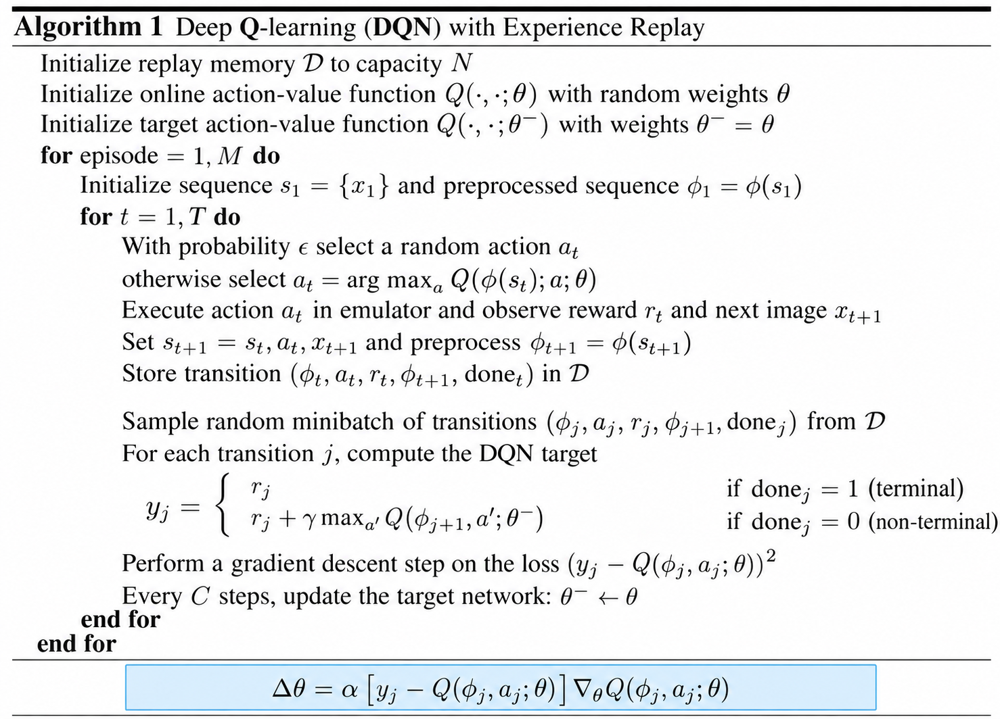



```text
Input:
    environment, number of episodes M, discount gamma
    replay capacity N, mini-batch size B, warm-up transitions W
    epsilon exploration schedule, target synchronization interval C
    online Q-network parameters theta, optimizer learning rate eta

Initialize:
    online Q-network Q(s, a; theta) with random weights
    target Q-network Q(s, a; theta_minus)
    copy theta -> theta_minus
    empty replay buffer D of maximum size N
    total_environment_steps = 0

For episode = 1 ... M:
    reset environment -> initial state s
    episode_reward = 0

    Repeat until environment terminates or truncates:
        1. Observe s and calculate epsilon(total_environment_steps)
        2. With probability epsilon: select a uniformly random action
           Otherwise: a = argmax_a Q(s, a; theta)
        3. Execute a in environment -> (s_next, r, terminated, truncated)
        4. Store (s, a, r, s_next, terminated) in replay buffer D
        5. Set s = s_next; accumulate episode_reward += r
        6. If len(D) >= max(W, B):
              6.1 Randomly sample B transitions from D
              6.2 Predict q_j = Q(s_j, a_j; theta) for chosen actions
              6.3 With no gradients, compute target for each transition:
                      y_j = r_j + gamma*(1-terminated_j)
                                          * max_a Q(s_next_j, a; theta_minus)
              6.4 Calculate loss L = (1/(2B)) sum_j (y_j - q_j)^2
              6.5 Clear grads; backpropagate L; optimizer step on theta
        7. total_environment_steps += 1
        8. If total_environment_steps modulo C == 0:
              copy online weights theta -> theta_minus
        9. If terminated OR truncated: end current episode

    Record episode reward, epsilon, and training loss

After training:
    Evaluate greedy policy (epsilon = 0) in fresh episodes
    Compare against random agent; save plots and rendered animation
```

**Link each line to mathematics:** Step 2 is action selection, step 4 provides off-policy experience, step 6.2 is $\hat y$, step 6.3 is $y$, step 6.4 is $L_B$, step 6.5 changes $\theta$, step 8 updates $\theta^-$. A stored `terminated` flag is used for bootstrapping; **both `terminated` and `truncated` stop the current environment rollout**.

### 12.1 Reading the algorithm without skipping steps

**Initialize only once**: (1) create online weights $\theta$; (2) copy them into target weights $\theta^-$; (3) make an empty replay buffer $\mathcal D$; (4) choose hyperparameters and a global environment-step counter. **Do not reinitialize networks when a new episode starts.**

For **each environment step**, follow the exact order:

1. **Observe** $s_t$ and compute $\varepsilon_t$. Random exploration happens with probability $\varepsilon_t$; otherwise choose $\arg\max_a Q(s_t,a;\theta)$ using the **online network**.
2. **Execute** $a_t$, observe $r_{t+1}$, $s_{t+1}$, `terminated`, and `truncated`.
3. **Store** $(s_t,a_t,r_{t+1},s_{t+1},\mathrm{terminated})$ in $\mathcal D$. The stored action can be exploratory and is not necessarily the current greedy choice.
4. **Wait** until the buffer contains enough experiences for training. This is replay warm-up; warm-up is **not** a new RL algorithm.
5. **Sample** $B$ transitions uniformly without replacement for this mini-batch. For each, predict $\hat y_j=Q(s_j,a_j;\theta)$ with the online network. Although the network outputs all actions, `gather` keeps the Q-value only for **the action actually taken** in each stored transition.
6. **Build** the targets from the target network, treating them as fixed for this optimizer step: $y_j=r_j+\gamma(1-d_j)\max_{a'}Q(s'_j,a';\theta^-)$. Set $d_j=1$ for true termination. This is one-step bootstrapping from an *estimate*, not a known true answer.
7. **Compute** $L_B=(1/(2B))\sum_j(y_j-\hat y_j)^2$. **Backpropagate** the loss and update **only $\theta$** through an optimizer such as Adam. The random mini-batch gives a stochastic gradient estimate.
8. **Synchronize** $\theta^-\leftarrow\theta$ at the chosen periodic environment-step interval. On other steps, the target network remains unchanged.
9. **Move** to $s_{t+1}$, and end the current rollout upon `terminated or truncated`. A truncation ends the rollout but, as used here, does **not** remove the bootstrap term. Begin the next episode using the **same trained weights and replay buffer**.

**One line summary:** Choose action with *online* $\to$ collect transition $\to$ replay sample $\to$ online chosen-action prediction $\to$ frozen next-state target $\to$ loss $\to$ online gradient update $\to$ occasional target copy.

### 12.2 Algorithm-to-equation checklist

For each sampled transition $i$:

1. **Input split:** online network receives $s_i$, target network receives $s'_i$.
2. **Chosen replay action:** $\hat y_i=Q(s_i,a_i;\theta)$; do not maximize this prediction across actions for the loss.
3. **Terminal mask:** $y_i=r_i$ for a true terminal; otherwise add estimated discounted future value.
4. **DQN target:** $y_i=r_i+\gamma(1-d_i)\max_{a'}Q(s'_i,a';\theta^-)$. Treat it as constant during gradient calculation.
5. **One mini-batch update:** compute $L_B=\frac1{2B}\sum_i(y_i-\hat y_i)^2$, then backpropagate once and update **online** weights only.
6. **Hard sync:** periodically copy the online parameters to the target network after the optimizer update.

No target-network gradient step occurs. The replay buffer never estimates Q-values. The environment itself supplies the next-state observation.

## 13. Double DQN: why does standard DQN sometimes overestimate?

### 13.1 The limitation is **maximization bias**, not merely the moving target

Suppose there are two equally good next-state actions with true values $q^*(s',0)=q^*(s',1)=5$. A noisy estimator sometimes gives $[7,3]$ and sometimes $[3,7]$, each equally likely. Both individual action estimates have mean $5$, but **the maximum is always 7**:

$$\mathbb E[Q(s',0)]=\mathbb E[Q(s',1)]=5,\qquad\mathbb E[\max_a Q(s',a)]=7>\max_a\mathbb E[Q(s',a)]=5.$$

More generally, $\mathbb E[\max_a \widehat Q_a]\geq\max_a\mathbb E[\widehat Q_a]$: taking a maximum of noisy action estimates can introduce an optimistic bias. The frozen target network slows target changes, **but does not remove the max operator**.

### 13.2 What exactly changes in Double DQN?

Standard DQN uses the target network both to **choose** the largest value and to **read** that largest value:

$$\boxed{y^{\mathrm{DQN}}=r+\gamma(1-d)\max_{a'}Q(s',a';\theta^-).}$$

Double DQN keeps the existing online and target networks, but **decouples selection from evaluation**:

$$\boxed{a^*_{\mathrm{online}}=\arg\max_{a'}Q(s',a';\theta)}\quad\text{(which next action?)},$$

$$\boxed{y^{\mathrm{DoubleDQN}}=r+\gamma(1-d)Q(s',a^*_{\mathrm{online}};\theta^-)}\quad\text{(how much is it worth?).}$$

Notice what stays **the same**: the recorded-action prediction $Q(s,a;\theta)$, mini-batch loss, gradient/backpropagation, replay buffer, epsilon-greedy behavior, and periodic target-network copy. There is **no third network** and **no policy-gradient objective**.

| Operation | DQN | Double DQN |
|---|---|---|
| Select best action at $s'$ | Target network | Online network |
| Evaluate selected action at $s'$ | Target network | Target network |
| Optimize chosen replay-action prediction | Online network | Online network |
| Update target weights | Periodic copy | Periodic copy |

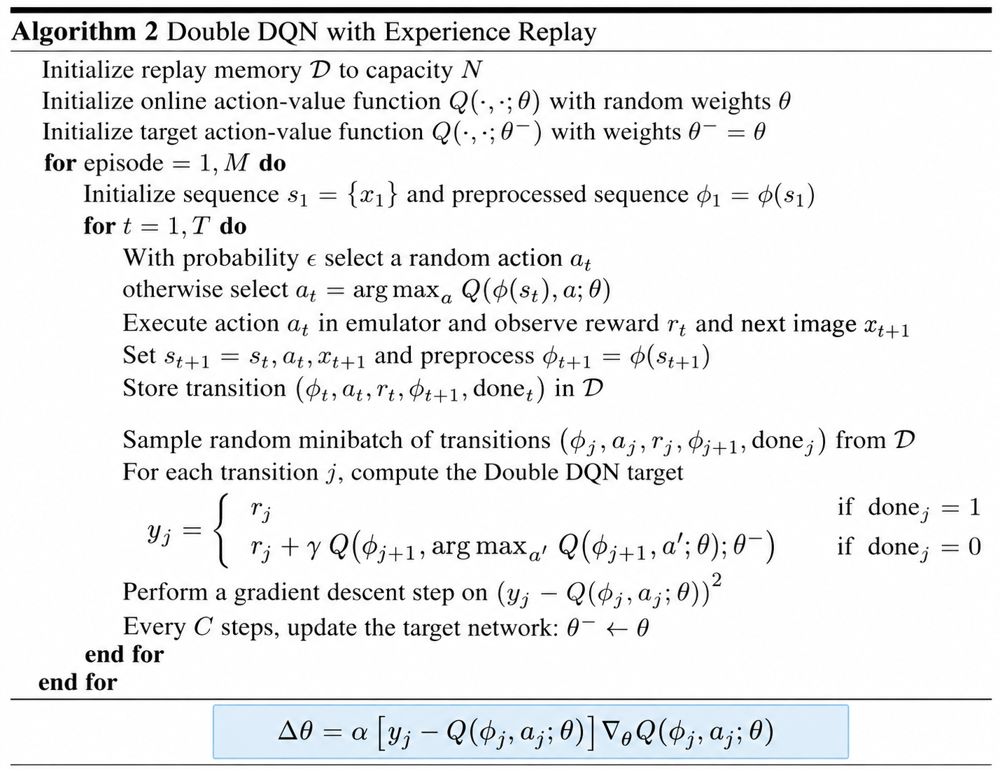

**The main advantage of Double DQN over DQN is that it reduces Q-value overestimation, which can improve learning stability and policy performance.**
- DQN: The target network both selects the best next action and estimates its Q-value. This can lead to overestimation.
- Double DQN: The online network selects the best next action, while the target network evaluates that action.

By separating action selection from evaluation, Double DQN generally produces less biased Q-value estimates and can learn better policies. However, better performance is not guaranteed in every environment.



### 13.3 Fully worked numerical comparison

Consider one nonterminal replay transition with reward $r=1$, discount $\gamma=0.9$, and chosen-current-action prediction $Q(s,a;\theta)=4.0$.

For **the next state $s'$**, suppose the two networks currently disagree:

| Next action | Online $Q(s',a';\theta)$ | Target $Q(s',a';\theta^-)$ |
|---|---:|---:|
| $a'=0$ | **8** | 5 |
| $a'=1$ | 6 | **7** |

**Standard DQN calculations:**

1. Choose the largest **target-network** output: $\max(5,7)=7$, corresponding to action 1.
2. Construct the Bellman target: $\boxed{y_{\mathrm{DQN}}=1+0.9(7)=7.3}$.
3. Compare to online prediction $4.0$: $e_{\mathrm{DQN}}=7.3-4.0=3.3$.
4. Half-squared error: $\boxed{L_{\mathrm{DQN}}=\tfrac12(3.3)^2=5.445}$.

**Double DQN calculations:**

1. **Online network selects**: $\arg\max(8,6)=\boxed{a^*=0}$.
2. **Target network evaluates that action**: $Q(s',0;\theta^-)=\boxed{5}$ (not the maximum target-network Q-value of 7).
3. Bellman target: $\boxed{y_{\mathrm{DoubleDQN}}=1+0.9(5)=5.5}$.
4. Error: $e_{\mathrm{DoubleDQN}}=5.5-4.0=1.5$.
5. Half-squared error: $\boxed{L_{\mathrm{DoubleDQN}}=\tfrac12(1.5)^2=1.125}$.

**Interpretation:** Here Double DQN produces a smaller target because the two networks disagree about which next action is best. **That alone does not prove $5.5$ is the true value or that Double DQN is always smaller/better on every transition.** The general benefit is reduced *average maximization-related overestimation* when selection and evaluation errors are not perfectly coupled; the networks still share training history and are correlated.

**Terminal case:** When $d=1$, the bootstrap is zero for *both*: $y^{\mathrm{DQN}}=y^{\mathrm{DoubleDQN}}=r$.

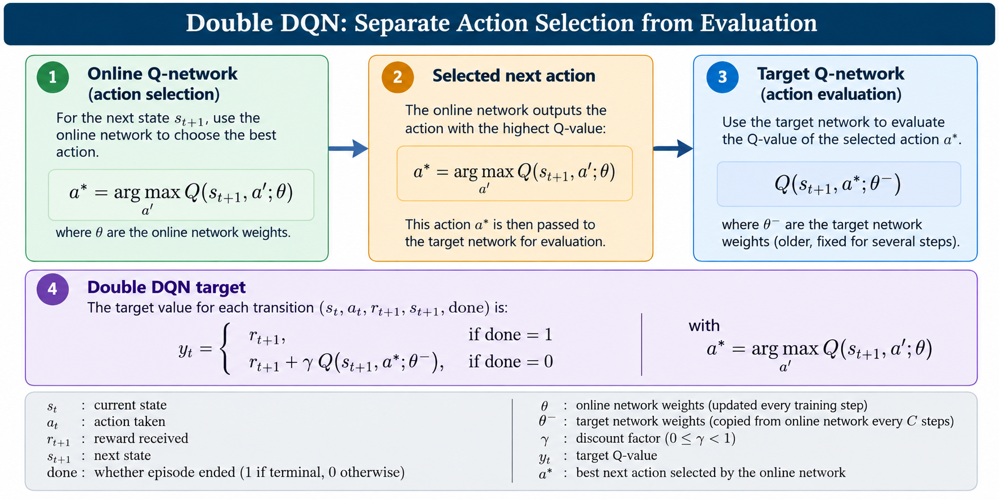

In [7]:
# Verify each number in the side-by-side DQN vs Double DQN hand calculation.
import torch
r, gamma, predicted_q = 1.0, 0.9, 4.0
q_next_online = torch.tensor([8.0, 6.0])
q_next_target = torch.tensor([5.0, 7.0])

standard_selected = int(torch.argmax(q_next_target))
double_selected = int(torch.argmax(q_next_online))
dqn_y = r + gamma * q_next_target.max().item()
double_y = r + gamma * q_next_target[double_selected].item()
dqn_loss = 0.5 * (dqn_y - predicted_q) ** 2
double_loss = 0.5 * (double_y - predicted_q) ** 2
print(f"DQN: select via target a={standard_selected}, target={dqn_y:.3f}, TD error={dqn_y-predicted_q:.3f}, half-MSE={dqn_loss:.3f}")
print(f"Double DQN: select via online a={double_selected}, evaluate via target, target={double_y:.3f}, TD error={double_y-predicted_q:.3f}, half-MSE={double_loss:.3f}")
assert standard_selected == 1 and double_selected == 0
assert abs(dqn_y - 7.3) < 1e-6 and abs(double_y - 5.5) < 1e-6
assert abs(dqn_loss - 5.445) < 1e-6 and abs(double_loss - 1.125) < 1e-6
assert r + gamma * (1 - 1) * q_next_target.max().item() == r

DQN: select via target a=1, target=7.300, TD error=3.300, half-MSE=5.445
Double DQN: select via online a=0, evaluate via target, target=5.500, TD error=1.500, half-MSE=1.125


### 13.4 One more numerical illustration of maximization bias (sampling noise)

The earlier example shows that two networks may select different actions. Here the calculation explains **why taking a maximum can be biased** even if individual predictions are unbiased. For equally valuable actions, randomly overestimating whichever action happens to look best raises $\mathbb E[\max]$. The following small experiment is synthetic; it is **not** an Atari/CartPole performance result.

In [8]:
# Illustrative biased maximum: the true value of BOTH actions is 5.
import numpy as np
rng = np.random.default_rng(42)
noise = rng.normal(loc=0, scale=1.0, size=(100_000, 2))
noisy_estimates = 5.0 + noise
mean_each = noisy_estimates.mean(axis=0)
mean_max = noisy_estimates.max(axis=1).mean()
print("Mean value estimated for each action:", np.round(mean_each, 3))
print("True maximum action value: 5.0")
print("Mean of the maximum of noisy estimates:", round(mean_max, 3))
assert mean_max > 5.2

Mean value estimated for each action: [4.998 5.001]
True maximum action value: 5.0
Mean of the maximum of noisy estimates: 5.566


### 13.5 Implementation: the **one change** from DQN to Double DQN

In the PyTorch optimizer below, the same two networks are already available. Standard DQN takes `max` over `target_net(next_states)`. Double DQN first takes `argmax` over `online_net(next_states)`, then **gathers the corresponding values** from `target_net(next_states)`.

```python
# DQN (one target-network pass: select + evaluate)
next_q = target_net(next_states).max(dim=1).values

# Double DQN (online selects; target evaluates)
next_actions = online_net(next_states).argmax(dim=1, keepdim=True)
next_q = target_net(next_states).gather(1, next_actions).squeeze(1)
```

Both calculations happen inside `with torch.no_grad()` during target construction. The current-state online prediction `online_net(states).gather(...)`, loss, and optimizer step remain unchanged. In the experiment, change `ALGORITHM = "dqn"` to `ALGORITHM = "double_dqn"` to train with the alternate target. For a fair performance study, run both under comparable interaction budgets and *multiple seeds*; one training run does not establish superiority.

## 14. Original Atari DQN

Mnih and colleagues' **2013** preprint *Playing Atari with Deep Reinforcement Learning* demonstrated learning control from visual input with a deep Q-network. It is useful background, but we will use a much lighter CartPole experiment so this notebook runs in Colab without long Atari training.

- **Preprocessing:** images converted to grayscale/downsampled and four recent processed frames stacked. The input to the early Atari DQN CNN is $84\times84\times4$ (frame history helps infer motion from images).
- **Conv layer 1 (2013 preprint architecture):** 16 filters of size $8\times8$, stride 4, ReLU, giving $20\times20\times16$ under valid padding.
- **Conv layer 2:** 32 filters of size $4\times4$, stride 2, ReLU, giving $9\times9\times32$.
- **Fully connected:** flatten $9\cdot9\cdot32=2592$ to 256 ReLU units.
- **Output:** linear head with one unit per legal action (historical Atari action sets vary by game). This 2013 architecture should not be confused with the later **2015 Nature DQN** architecture.
- **Training mechanics:** epsilon-greedy exploration, replay memory, gradient-based TD learning; frame skipping and clipped rewards ($\operatorname{sign}(r)\in\{-1,0,1\}$) were part of the setup discussed in the original experiments.

For a visual stream, one screenshot may be insufficient to determine speed and direction, so a fixed-length **stack of consecutive frames** is useful. The input transformation can be written

$$\phi_t=\phi(o_{t-3},o_{t-2},o_{t-1},o_t),\qquad Q(\phi_t,a;\theta).$$


**Related research application:** *Learning to Schedule Control Fragments for Physics-Based Characters Using Deep Q-Learning* (Liu & Hodgins, 2017). It uses Q-learning to select from a finite set of precomputed control fragments in a physical character simulator; the complex continuous motion is generated by the simulator/controllers, while the Q-network selects the fragment/action index. This is a demonstration of DQN beyond Atari, **not** the environment implemented here.

## 15. CartPole-v1: task definition and Gymnasium environment

We will learn to keep a pole balanced on a moving cart. The **state/observation** is a four-element continuous vector:

$$s_t=[\underbrace{x}_{\text{cart position}},\underbrace{\dot x}_{\text{cart velocity}},\underbrace{\varphi}_{\text{pole angle}},\underbrace{\dot\varphi}_{\text{pole angular velocity}}]^T.$$

The **action space** is $\{0:\text{push left},1:\text{push right}\}$. By default, the **reward** is $+1$ for each step, even the terminating step. A true termination occurs if the pole angle exceeds about $\pm12^\circ$ or cart position exceeds $\pm2.4$; CartPole-v1 also has a **500-step time limit** (truncation). The objective is to maximize episode return, which here equals episode length under the default reward.

**Why this environment?** Its **continuous observations** make an exact Q-table unsuitable, while its **two discrete actions** match standard DQN's action-value vector output. The observation is **already a four-number vector**, not raw pixels, so this exercise appropriately uses an **MLP**, rather than pretending that a CNN is required.

Reference: [Gymnasium CartPole documentation](https://gymnasium.farama.org/environments/classic_control/cart_pole/).

In [9]:
# Run this once in Google Colab. The remaining notebook uses PyTorch, Gymnasium and imageio.
%pip -q install "gymnasium[classic-control]>=1.0,<1.4" imageio imageio-ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 79.9 MB/s eta 0:00:00


In [10]:
import os, random, math
from collections import deque
from pathlib import Path
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from IPython.display import display, Image
import imageio.v2 as imageio

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESULTS_DIR = Path("results")
MODELS_DIR = Path("models")
RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
print("PyTorch:", torch.__version__, "| Gymnasium:", gym.__version__, "| Device:", device)

PyTorch: 2.11.0+cpu | Gymnasium: 1.3.0 | Device: cpu


In [11]:
# Inspect the real environment and one random transition.
env_check = gym.make("CartPole-v1")
observation, info = env_check.reset(seed=SEED)
env_check.action_space.seed(SEED)
a_random = env_check.action_space.sample()
next_observation, reward, terminated, truncated, info = env_check.step(a_random)
print("Observation space:", env_check.observation_space)
print("Action space:", env_check.action_space)
print("Initial state:", np.round(observation, 4))
print("Random action:", a_random, "| Reward:", reward, "| Terminated:", terminated, "| Truncated:", truncated)
print("Next state:", np.round(next_observation, 4))
env_check.close()

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Initial state: [ 0.0274 -0.0061  0.0359  0.0197]
Random action: 0 | Reward: 1.0 | Terminated: False | Truncated: False
Next state: [ 0.0273 -0.2017  0.0363  0.3235]


## 16. Implement a PyTorch Q-network

For a batch of $B$ states, network input shape is $(B,4)$ and output shape is $(B,2)$. For a replay action vector $a\in\{0,1\}^B$, `gather` selects the relevant action-value prediction:

$$
\mathrm{all\_q}[j,:]=[Q(s_j,0),Q(s_j,1)],\qquad \mathrm{selected\_q}[j]=Q(s_j,a_j)
$$

There is no softmax: output values can be negative or positive, and both may move as training proceeds.

In [12]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(state_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, action_dim))

    def forward(self, states):
        return self.net(states)

demo_model = QNetwork(state_dim=4, action_dim=2).to(device)
demo_input = torch.tensor([[0.02, 0.10, -0.03, -0.12]], dtype=torch.float32, device=device)
print(demo_model)
print("Example output [Q(s,0), Q(s,1)]:", demo_model(demo_input).detach().cpu().numpy())
print("Total trainable parameters:", sum(p.numel() for p in demo_model.parameters()))
assert tuple(demo_model(demo_input).shape) == (1, 2)

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)
Example output [Q(s,0), Q(s,1)]: [[ 0.02412461 -0.01777463]]
Total trainable parameters: 17410


## 17. Implement uniform replay memory

Replay holds only **past observed transitions**, never the whole underlying environment transition model. In the next cell, stored `terminated` is intentionally different from `terminated or truncated`: the latter tells the environment when an episode ends; the former tells the Bellman update when to **disable** bootstrapping.

In [13]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, terminated):
        transition = (np.asarray(state, dtype=np.float32).copy(), int(action), float(reward), np.asarray(next_state, dtype=np.float32).copy(), bool(terminated))
        self.buffer.append(transition)

    def sample(self, batch_size):
        samples = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, terminated = zip(*samples)
        return np.stack(states), np.asarray(actions, dtype=np.int64), np.asarray(rewards, dtype=np.float32), np.stack(next_states), np.asarray(terminated, dtype=np.float32)

    def __len__(self):
        return len(self.buffer)

replay_test = ReplayBuffer(3)
for i in range(4): replay_test.push([i, 0, 0, 0], i % 2, 1.0, [i+1, 0, 0, 0], i == 3)
print("Capacity 3; inserted 4 transitions; retained:", len(replay_test))
print("Mini-batch shapes:", [a.shape for a in replay_test.sample(2)])
assert len(replay_test) == 3

Capacity 3; inserted 4 transitions; retained: 3
Mini-batch shapes: [(2, 4), (2,), (2,), (2, 4), (2,)]


The buffer test above inserts four transitions into a capacity-three deque; it correctly retains only the most recent three. The sampled states and next states have shape $(B,4)$, while action/reward/termination vectors have shape $(B,)$. In the complete training loop, the stored termination flag is **not** set for an ordinary 500-step time-limit truncation; the loop still ends that episode.

## 18. Choose hyperparameters and epsilon schedule

The settings below are teaching defaults rather than universally optimal parameters. The `EPISODES` value sets training duration; depending on CPU/GPU and exploration, learning may be slow or unstable. **The notebook will measure actual results instead of assuming the pole will reach 500 steps.**

We use exponential **per-environment-step** epsilon decay:

$$\boxed{\varepsilon_t=\varepsilon_{\min}+(\varepsilon_{\max}-\varepsilon_{\min})e^{-t/\tau}}.$$

Initially, $\varepsilon_0=1$ (full exploration); as $t$ grows, epsilon approaches $0.05$ without reaching zero during training. For evaluation we deliberately choose **greedy actions** ($\varepsilon=0$).
The next hyperparameter cell also exposes `ALGORITHM`, which selects the target rule. Leave `"dqn"` as the default for standard DQN; choose `"double_dqn"` to run the extension. Rerun the training and plotting/evaluation cells after changing it.

In [14]:
ALGORITHM = "dqn"              # choose "dqn" or "double_dqn"; train one at a time
EPISODES = 400
GAMMA = 0.99
LEARNING_RATE = 1e-3
BATCH_SIZE = 64
BUFFER_CAPACITY = 30_000
LEARNING_STARTS = 1_000
TARGET_UPDATE_INTERVAL = 250      # hard copy every 250 environment steps
EPS_START, EPS_END, EPS_DECAY = 1.0, 0.05, 12_000
EVAL_EPISODES = 20
PRINT_EVERY = 25

def epsilon_by_step(step):
    return EPS_END + (EPS_START - EPS_END) * math.exp(-step / EPS_DECAY)

for step in (0, 1000, 5000, 12000, 30000):
    print(f"Step {step:5d}: epsilon = {epsilon_by_step(step):.4f}")
assert ALGORITHM in ("dqn", "double_dqn"), "Choose dqn or double_dqn"
print("Training algorithm:", ALGORITHM)

# Preserve DQN filenames; prefix Double DQN outputs so the two runs do not overwrite each other.
def result_name(filename):
    return filename if ALGORITHM == "dqn" else f"double_dqn_{filename}"

Step     0: epsilon = 1.0000
Step  1000: epsilon = 0.9240
Step  5000: epsilon = 0.6763
Step 12000: epsilon = 0.3995
Step 30000: epsilon = 0.1280
Training algorithm: dqn


## 19. Action selection and a complete optimizer step

**Watch the code-to-equation mapping:**

- `online_net(states).gather(...)` is $\hat y_j=Q(s_j,a_j;\theta)$.
- **DQN:** `target_net(next_states).max(dim=1).values` selects and evaluates the next action with the target network.
- **Double DQN:** `online_net(next_states).argmax(...)` selects; `target_net(next_states).gather(...)` evaluates.
- `targets = rewards + GAMMA * (1.0 - terminated) * next_q` is the Bellman target $y_j$.
- `0.5 * F.mse_loss(predicted_q, targets)` is **exactly the half-MSE** introduced in Section 8 (averaged over $B$).
- `loss.backward()` calculates gradients by the chain rule; `optimizer.step()` changes **only online** network weights.
- `with torch.no_grad()` and frozen target parameters keep the target fixed for this step.

An SGD optimizer would follow the hand-worked $\theta\leftarrow\theta-\alpha\nabla L$. Adam uses the same gradients but adjusts learning rates across parameters.
**Choose method:** `ALGORITHM="dqn"` reproduces the original standard DQN target; `ALGORITHM="double_dqn"` uses Double DQN. Neither choice modifies the network architecture or replay format.

In [15]:
def select_action(state, online_net, epsilon, action_space):
    if random.random() < epsilon:
        return action_space.sample()
    state_tensor = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        return int(online_net(state_tensor).argmax(dim=1).item())


def optimize_dqn(online_net, target_net, replay_buffer, optimizer, batch_size=BATCH_SIZE, algorithm="dqn"):
    """Optimize ONLINE parameters only. Double DQN changes only bootstrap next-Q estimation."""
    if algorithm not in ("dqn", "double_dqn"):
        raise ValueError("algorithm must be 'dqn' or 'double_dqn'")
    states, actions, rewards, next_states, terminated = replay_buffer.sample(batch_size)
    states = torch.as_tensor(states, dtype=torch.float32, device=device)
    actions = torch.as_tensor(actions, dtype=torch.long, device=device)
    rewards = torch.as_tensor(rewards, dtype=torch.float32, device=device)
    next_states = torch.as_tensor(next_states, dtype=torch.float32, device=device)
    terminated = torch.as_tensor(terminated, dtype=torch.float32, device=device)

    # Online-network prediction of the action actually recorded in the replay sample.
    predicted_q = online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        if algorithm == "dqn":
            next_q = target_net(next_states).max(dim=1).values  # Target selects and evaluates.
        else:
            next_actions = online_net(next_states).argmax(dim=1, keepdim=True)  # Online SELECTS.
            next_q = target_net(next_states).gather(1, next_actions).squeeze(1)  # Target EVALUATES.
        targets = rewards + GAMMA * (1.0 - terminated) * next_q

    loss = 0.5 * F.mse_loss(predicted_q, targets)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(online_net.parameters(), max_norm=10.0)
    optimizer.step()
    return float(loss.item())

**How batch dimensions move through this function (for $B=64$):**

| Tensor | Shape | Interpretation |
|---|---|---|
| `states`, `next_states` | `(64, 4)` | A current and next observation for every sampled experience |
| `online_net(states)` | `(64, 2)` | Two predicted action-values for every current state |
| `actions` | `(64,)` | Recorded replay actions; one per row |
| `predicted_q` | `(64,)` | Exactly one selected online output per transition (`gather`) |
| `next_q`, `targets` | `(64,)` | One bootstrap estimate and one Bellman target per transition |
| `loss` | scalar | Mean half-squared error for the batch |

When `loss.backward()` runs, all 64 samples contribute to the online network's gradient. **One** `optimizer.step()` then updates the weights. Neither the replay memory nor the target network is optimized by that step. Gradient clipping limits the norm of a computed gradient; it does not change which network is trained.

## 20. Run the complete DQN training loop

For each new experience: act $\to$ step $\to$ store transition $\to$ (after replay warm-up) sample a batch and update online network $\to$ periodically copy online weights to target. We collect one total reward per episode and individual optimizer losses. This can take several minutes in Colab.

`torch.set_num_threads` is left to the environment defaults; if CPU performance is slow, trying a smaller hidden size or fewer episodes is reasonable. **Do not interpret an early noisy reward curve as proof of convergence.**
**Initialization occurs before the episode loop**, and continues across episodes. The target-network copy is determined by a **global environment-step count**. `ALGORITHM` selects the Bellman target while the rest of the loop remains the same.

In [16]:
import gymnasium as gym

train_env = gym.make("CartPole-v1")
train_env.action_space.seed(SEED)
state_dim = train_env.observation_space.shape[0]
action_dim = train_env.action_space.n
online_net = QNetwork(state_dim, action_dim).to(device)
target_net = QNetwork(state_dim, action_dim).to(device)
target_net.load_state_dict(online_net.state_dict())
target_net.eval()
for p in target_net.parameters(): p.requires_grad_(False)
optimizer = torch.optim.Adam(online_net.parameters(), lr=LEARNING_RATE)
replay_buffer = ReplayBuffer(BUFFER_CAPACITY)

rewards_history, epsilon_history, losses_history = [], [], []
total_steps, optimizer_updates = 0, 0
for episode in range(1, EPISODES + 1):
    state, info = train_env.reset(seed=SEED + episode)
    episode_reward = 0.0
    while True:
        epsilon = epsilon_by_step(total_steps)
        action = select_action(state, online_net, epsilon, train_env.action_space)
        next_state, reward, terminated, truncated, info = train_env.step(action)
        replay_buffer.push(state, action, reward, next_state, terminated)
        state = next_state
        episode_reward += reward
        total_steps += 1

        if len(replay_buffer) >= max(LEARNING_STARTS, BATCH_SIZE):
            losses_history.append(optimize_dqn(online_net, target_net, replay_buffer, optimizer, algorithm=ALGORITHM))
            optimizer_updates += 1
        if total_steps % TARGET_UPDATE_INTERVAL == 0:
            target_net.load_state_dict(online_net.state_dict())
        if terminated or truncated:
            break

    rewards_history.append(episode_reward)
    epsilon_history.append(epsilon_by_step(total_steps))
    if episode == 1 or episode % PRINT_EVERY == 0:
        print(f"Episode {episode:3d}/{EPISODES} | reward={episode_reward:5.0f} | last-20 avg={np.mean(rewards_history[-20:]):6.1f} | epsilon={epsilon_history[-1]:.3f} | replay={len(replay_buffer)}")

train_env.close()
torch.save({"model_state_dict": online_net.state_dict(), "state_dim": state_dim, "action_dim": action_dim, "episodes": EPISODES, "seed": SEED, "algorithm": ALGORITHM}, MODELS_DIR / f"{ALGORITHM}_cartpole.pt")
print(f"Training finished. Environment steps: {total_steps}; optimizer updates: {optimizer_updates}; model saved to {MODELS_DIR / f'{ALGORITHM}_cartpole.pt'}")

Episode   1/400 | reward=   21 | last-20 avg=  21.0 | epsilon=0.998 | replay=21
Episode  25/400 | reward=   22 | last-20 avg=  24.9 | epsilon=0.950 | replay=649
Episode  50/400 | reward=   24 | last-20 avg=  20.2 | epsilon=0.912 | replay=1162
Episode  75/400 | reward=   16 | last-20 avg=  17.6 | epsilon=0.882 | replay=1587
Episode 100/400 | reward=   26 | last-20 avg=  26.0 | epsilon=0.840 | replay=2211
Episode 125/400 | reward=   29 | last-20 avg=  28.2 | epsilon=0.790 | replay=2996
Episode 150/400 | reward=   11 | last-20 avg=  29.1 | epsilon=0.741 | replay=3819
Episode 175/400 | reward=   33 | last-20 avg=  43.6 | epsilon=0.685 | replay=4836
Episode 200/400 | reward=   98 | last-20 avg=  47.5 | epsilon=0.628 | replay=5970
Episode 225/400 | reward=  148 | last-20 avg=  45.4 | epsilon=0.576 | replay=7084
Episode 250/400 | reward=   54 | last-20 avg=  48.2 | epsilon=0.524 | replay=8352
Episode 275/400 | reward=   14 | last-20 avg=  48.6 | epsilon=0.473 | replay=9714
Episode 300/400 | r

## 21. Plot training **rewards**, loss, and epsilon

We plot the **actual episode rewards** first (as requested for a transparent learning curve). The separate smoothed reward curve is only a visualization aid, not new data. Loss may fluctuate because targets change and batches come from replay; a falling loss alone does **not** prove a better policy. In CartPole the maximum default episode reward is 500.
Plot titles refer to the selected algorithm (`ALGORITHM`); the same plots can be regenerated after changing the training variant.

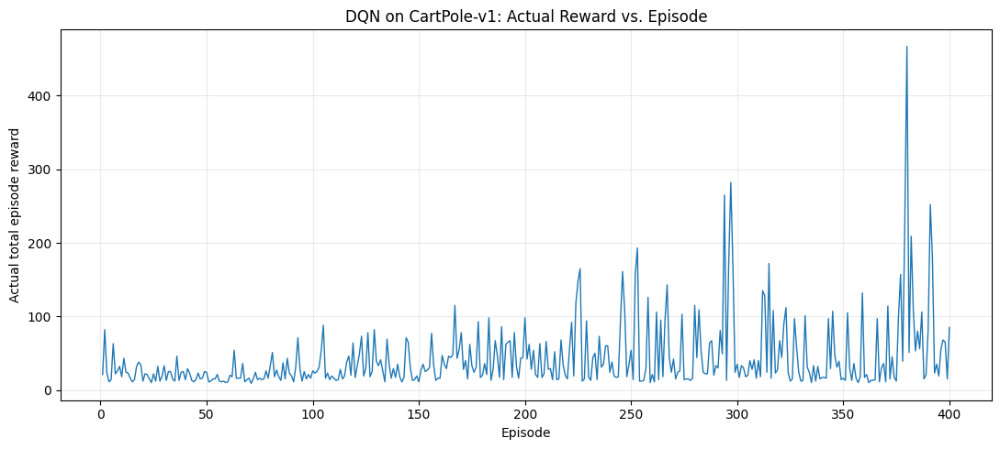

In [17]:
# Plot 1 — Actual episode reward without smoothing.
plt.figure(figsize=(11, 5))
plt.plot(np.arange(1, len(rewards_history) + 1), rewards_history, linewidth=1.0)
plt.xlabel("Episode")
plt.ylabel("Actual total episode reward")
plt.title(f"{ALGORITHM.upper()} on CartPole-v1: Actual Reward vs. Episode")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / result_name("reward_vs_episode.png"), dpi=170)
plt.show()

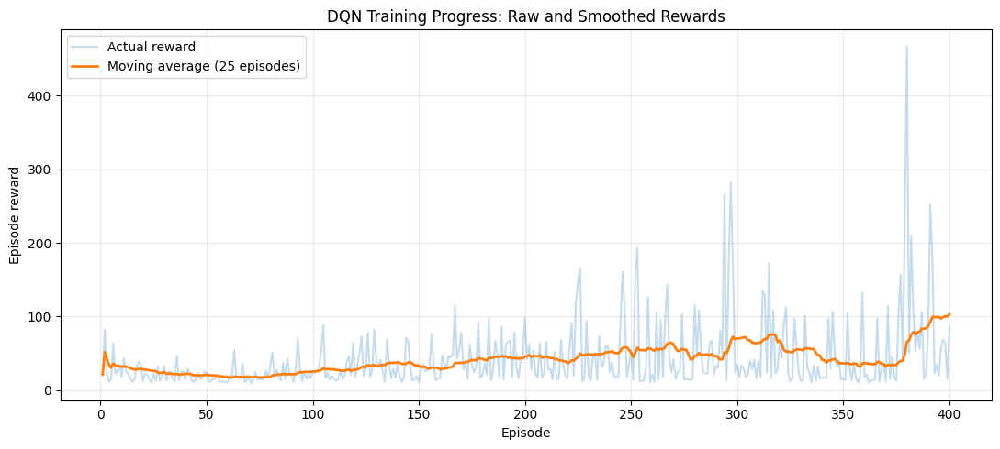

In [18]:
# Plot 2 — Separate moving average for readability; raw rewards remain available above.
window = 25
smoothed_rewards = pd.Series(rewards_history).rolling(window=window, min_periods=1).mean()
plt.figure(figsize=(11, 5))
plt.plot(range(1, len(rewards_history) + 1), rewards_history, alpha=0.25, label="Actual reward")
plt.plot(range(1, len(rewards_history) + 1), smoothed_rewards, linewidth=2, label=f"Moving average ({window} episodes)")
plt.xlabel("Episode")
plt.ylabel("Episode reward")
plt.title(f"{ALGORITHM.upper()} Training Progress: Raw and Smoothed Rewards")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / result_name("reward_with_moving_average.png"), dpi=170)
plt.show()

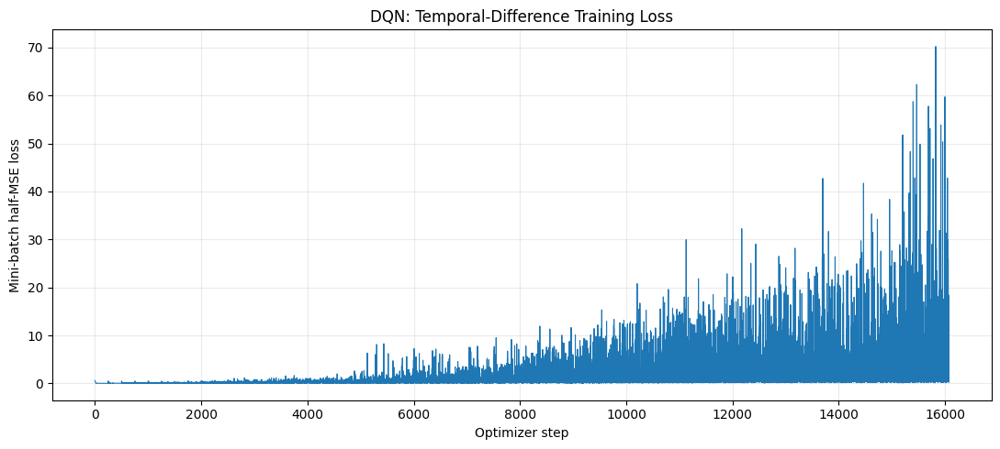

In [19]:
# Plot 3 — Mini-batch half-MSE over optimization steps.
plt.figure(figsize=(11, 5))
plt.plot(np.arange(1, len(losses_history) + 1), losses_history, linewidth=0.8)
plt.xlabel("Optimizer step")
plt.ylabel("Mini-batch half-MSE loss")
plt.title(f"{ALGORITHM.upper()}: Temporal-Difference Training Loss")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / result_name("training_loss.png"), dpi=170)
plt.show()

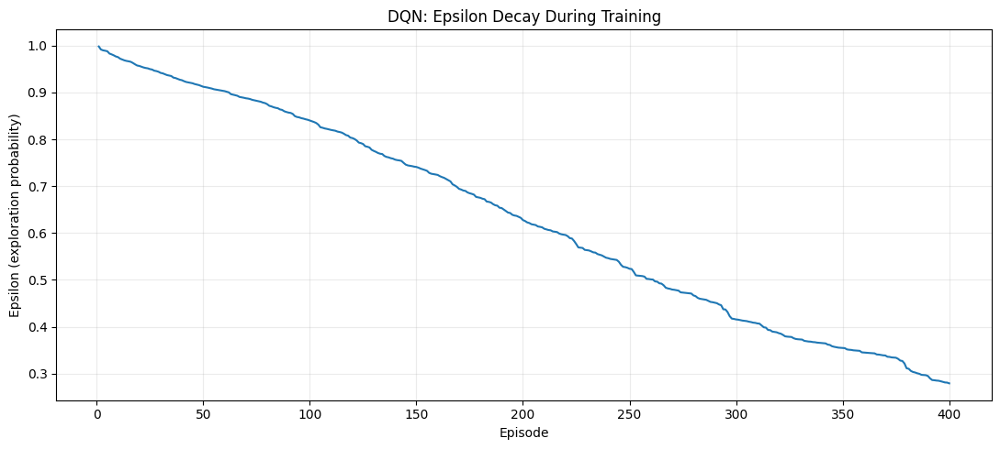

In [20]:
# Plot 4 — Epsilon at the end of each episode.
plt.figure(figsize=(11, 5))
plt.plot(np.arange(1, len(epsilon_history) + 1), epsilon_history)
plt.xlabel("Episode")
plt.ylabel("Epsilon (exploration probability)")
plt.title(f"{ALGORITHM.upper()}: Epsilon Decay During Training")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / result_name("epsilon_decay.png"), dpi=170)
plt.show()

## 22. Evaluate trained greedy policy versus a random baseline

**Evaluation is separate from training.** Use fixed seeds and *no* epsilon exploration for DQN; compare with a uniform random-action baseline under matching episode seeds. Mean, standard deviation and individual episode returns help reveal variability. Training and evaluation on the **same environment rules** does not imply generalization to different dynamics.

In [21]:
def evaluate_policy(policy_net=None, n_episodes=20, seed_start=1000):
    eval_env = gym.make("CartPole-v1")
    eval_env.action_space.seed(seed_start)
    returns = []
    for k in range(n_episodes):
        state, info = eval_env.reset(seed=seed_start + k)
        total_reward = 0.0
        while True:
            action = eval_env.action_space.sample() if policy_net is None else select_action(state, policy_net, epsilon=0.0, action_space=eval_env.action_space)
            state, reward, terminated, truncated, info = eval_env.step(action)
            total_reward += reward
            if terminated or truncated: break
        returns.append(total_reward)
    eval_env.close()
    return np.asarray(returns, dtype=float)

random_returns = evaluate_policy(policy_net=None, n_episodes=EVAL_EPISODES)
dqn_returns = evaluate_policy(policy_net=online_net, n_episodes=EVAL_EPISODES)
comparison = pd.DataFrame({"Policy": ["Uniform random", f"Trained {ALGORITHM.upper()} (greedy)"], "Mean return": [random_returns.mean(), dqn_returns.mean()], "Std return": [random_returns.std(ddof=1), dqn_returns.std(ddof=1)], "Min": [random_returns.min(), dqn_returns.min()], "Max": [random_returns.max(), dqn_returns.max()]})
display(comparison.round(2))
comparison.to_csv(RESULTS_DIR / result_name("evaluation_summary.csv"), index=False)
print("Individual random-agent returns:", random_returns.astype(int).tolist())
print(f"Individual trained {ALGORITHM.upper()} returns:", dqn_returns.astype(int).tolist())

,Policy,Mean return,Std return,Min,Max
0,Uniform random,22.95,14.20,10.0,62.0
1,Trained DQN (greedy),208.90,45.39,142.0,317.0


Individual random-agent returns: [38, 62, 12, 11, 22, 23, 23, 12, 26, 17, 10, 19, 14, 15, 10, 16, 40, 51, 20, 18]
Individual trained DQN returns: [317, 168, 144, 234, 248, 224, 238, 212, 221, 253, 187, 249, 214, 149, 173, 185, 229, 154, 142, 237]


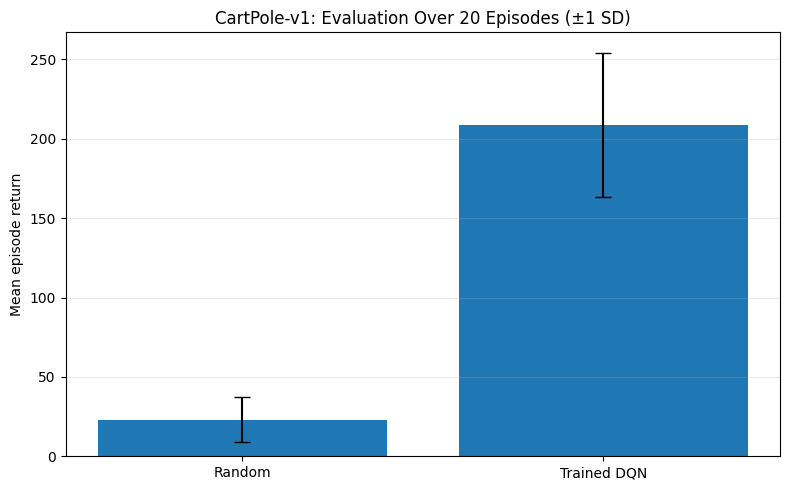

In [22]:
# Plot 5 — Head-to-head evaluation using independent completed episodes.
positions = np.arange(2)
means = [random_returns.mean(), dqn_returns.mean()]
stds = [random_returns.std(ddof=1), dqn_returns.std(ddof=1)]
plt.figure(figsize=(8, 5))
plt.bar(positions, means, yerr=stds, capsize=6)
plt.xticks(positions, ["Random", f"Trained {ALGORITHM.upper()}"])
plt.ylabel("Mean episode return")
plt.title(f"CartPole-v1: Evaluation Over {EVAL_EPISODES} Episodes (±1 SD)")
plt.ylim(bottom=0)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / result_name("evaluation_comparison.png"), dpi=170)
plt.show()

## 23. Inspect learned Q-values at selected states

Unlike tabular Q-learning, DQN **does not produce an optimal Q-table** with one row for every possible continuous state. Instead, we can **query its approximate Q-function** for selected states and display the greedy decision. Note that approximate Q-values may be inaccurate outside the distribution visited during training.

In [23]:
example_states = np.array([[0.00, 0.00, 0.00, 0.00], [0.00, 0.15, 0.04, 0.00], [0.00, -0.15, -0.04, 0.00], [0.05, 0.05, 0.08, -0.10]], dtype=np.float32)
with torch.no_grad():
    sample_q_values = online_net(torch.as_tensor(example_states, device=device)).cpu().numpy()
q_diagnostics = pd.DataFrame(np.column_stack([example_states, sample_q_values, np.argmax(sample_q_values, axis=1)]), columns=["Cart x", "Cart velocity", "Pole angle", "Pole angular vel.", "Q(left)", "Q(right)", "Greedy action"])
display(q_diagnostics.round(4))
q_diagnostics.to_csv(RESULTS_DIR / result_name("selected_state_q_values.csv"), index=False)

,Cart x,Cart velocity,Pole angle,Pole angular vel.,Q(left),Q(right),Greedy action
0,0.00,0.00,0.00,0.0,57.9563,57.9853,1.0
1,0.00,0.15,0.04,0.0,57.4012,57.6088,1.0
2,0.00,-0.15,-0.04,0.0,59.7663,59.4721,0.0
3,0.05,0.05,0.08,-0.1,57.7124,58.7389,1.0


## 24. Visualize a trained greedy agent

`rgb_array` rendering works in Colab without opening a separate window. The next cell records one episode with the trained greedy network, saves an animated GIF under `results/`, and displays it inline. We sample every 2nd frame to keep the GIF smaller; the policy still acts at **every** environment step.

Greedy demo episode reward: 218 | frames stored: 110 | saved: results/trained_agent.gif


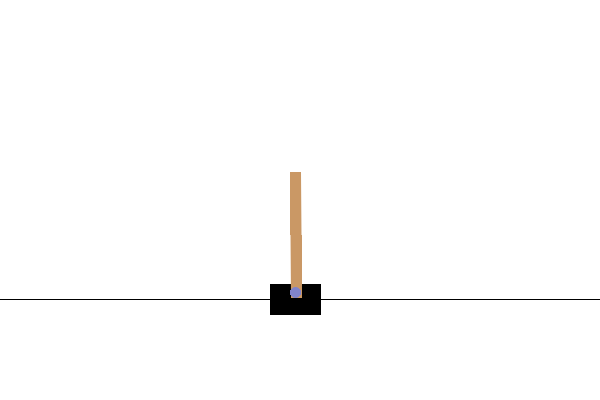

In [24]:
render_env = gym.make("CartPole-v1", render_mode="rgb_array")
state, info = render_env.reset(seed=2026)
frames = [render_env.render()]
video_reward = 0.0
for step in range(500):
    action = select_action(state, online_net, epsilon=0.0, action_space=render_env.action_space)
    state, reward, terminated, truncated, info = render_env.step(action)
    video_reward += reward
    if step % 2 == 0: frames.append(render_env.render())
    if terminated or truncated: break
render_env.close()
gif_path = RESULTS_DIR / result_name("trained_agent.gif")
imageio.mimsave(gif_path, frames, duration=0.06, loop=0)
print(f"Greedy demo episode reward: {video_reward:.0f} | frames stored: {len(frames)} | saved: {gif_path}")
display(Image(filename=str(gif_path)))

## 25. Diagnostics, interpretation, and limits of DQN

After execution, interpret **your actual plots**, rather than assuming a particular score:

1. **Rewards:** Do later *raw* episode rewards tend to exceed earlier rewards? Is performance repeatable, or does it collapse periodically?
2. **Evaluation:** Is the greedy agent's mean return greater than the random baseline over matched episode seeds? Are results consistent across episodes?
3. **Loss:** Does TD loss fluctuate? That can happen even during useful learning, because targets and replay distribution change.
4. **Epsilon:** Did the agent have a chance to explore early, and does evaluation use $\varepsilon=0$?
5. **Replay/target ablation (future experiment):** Holding the seed, training steps, and other hyperparameters fixed, compare with no replay and with targets set from the online net every step. Such variants **may** become unstable; results must be measured, not assumed.

**Limitations:** Approximate Q-learning is sensitive to target drift, hyperparameters, reward scales, replay composition, and bootstrapping error. Standard DQN can overestimate action values because of maximization over noisy predictions, and does not directly support continuous-action optimization. **Double DQN** addresses the selection/evaluation coupling (derived with numbers in Section 13):

$$\boxed{y^{\rm DoubleDQN}=r+\gamma(1-d)Q\left(s',\arg\max_a Q(s',a;\theta);\theta^-\right)}.$$

Other extensions include **Dueling DQN** (value/advantage decomposition) and **prioritized replay**. Actor-critic methods such as PPO, DDPG, and SAC belong to further chapters and are not implemented in this notebook.
**When comparing experiments:** A single seed and one final reward curve cannot establish that Double DQN improves performance. Use equal environment-step budgets, identical evaluation procedures, and several independent seeds. Reduced Q-value overestimation and higher episode reward are distinct quantities.

## 26. Recap: equations to remember

| Concept | Equation / meaning |
|---|---|
| Return | $G_t=\sum_{k=0}^{\infty}\gamma^kR_{t+k+1}$ |
| Tabular Q-learning | $Q(s,a)\leftarrow Q(s,a)+\alpha[r+\gamma\max_{a'}Q(s',a')-Q(s,a)]$ |
| DQN predictions | $\mathbf Q(s;\theta)=[Q(s,a_0),\ldots,Q(s,a_{m-1})]$ |
| Target (target network) | $y=r+\gamma(1-d)\max_{a'}Q(s',a';\theta^-)$ |
| Chosen-action prediction | $\hat y=Q(s,a;\theta)$ |
| TD error | $\delta=y-\hat y$ |
| Mini-batch half-MSE | $L=\frac1{2B}\sum_j(y_j-\hat y_j)^2$ |
| SGD (conceptual) | $\theta\leftarrow\theta+\frac\alpha B\sum_j\delta_j\nabla_\theta Q(s_j,a_j;\theta)$ |
| Double DQN | $a^*=\arg\max_{a'}Q(s',a';\theta)$, then $y=r+\gamma(1-d)Q(s',a^*;\theta^-)$ |
| Target sync | $\theta^-\leftarrow\theta$ every $C$ environment steps |
| Exploration | Uniform random action with probability $\varepsilon$; greedy otherwise |

**The core answer to “how do RL and DL integrate?”** The environment supplies experiences and scalar rewards; the Bellman equation turns each experience into a **training target**; a neural network predicts Q-values; a differentiable loss and backpropagation improve those predictions; repeated choices produce new experience. DQN adds **replay** and a **separate target network** to improve learning stability.

**Understand the distinction:** The two-network *DQN* is for a less rapidly moving bootstrap target. *Double DQN* **reuses those same networks**, choosing $a^*$ with the online network and evaluating $Q(s',a^*)$ with the target network to reduce maximization-related overestimation.

### References and documentation

- V. Mnih et al. (2013), *Playing Atari with Deep Reinforcement Learning*. [arXiv:1312.5602](https://arxiv.org/abs/1312.5602).
- V. Mnih et al. (2015), *Human-level control through deep reinforcement learning*. [Nature (2015)](https://doi.org/10.1038/nature14236).
- R. S. Sutton and A. G. Barto, *Reinforcement Learning: An Introduction*, 2nd ed., chapters on temporal difference learning and function approximation.
- H. van Hasselt, A. Guez, and D. Silver (2016), *Deep Reinforcement Learning with Double Q-learning*, AAAI. [arXiv:1509.06461](https://arxiv.org/abs/1509.06461).
- [Gymnasium tutorial: Handling Time Limits](https://gymnasium.farama.org/main/tutorials/handling_time_limits/).
- [Gymnasium CartPole-v1 documentation](https://gymnasium.farama.org/environments/classic_control/cart_pole/).
- [PyTorch documentation](https://pytorch.org/docs/stable/index.html).

*The equations, manual example, PyTorch implementation, and diagrams are independently written for this portfolio. Historical material in the original Atari study is identified as such.*